## Chapter 2 回帰結合型ニューラルネットワーク（RNN）
ここでは、回帰結合型ニューラルネットワーク（Recurrent Neural Network, RNN）について説明します。

これまで扱ってきた順伝播型ニューラルネットワーク（Feedforward Neural Network, FNN）と呼ばれるものは、入力層から出力層への伝播が一方向にしか行われないため、たとえば時系列データのような入力に対しては、その時点での入力のみを考慮して出力を決定することになります。一方でRNNは、時系列データのような入力に対して、その時点での入力だけでなく、それまでの入力に対する出力も考慮して出力を決定できます。

このような構造を持つニューラルネットワークを、再帰的（Recursive）な構造を持つといい、そのような構造を持つニューラルネットワークなので 再帰型ニューラルネットワーク と呼びます。



### Chapter 2.2 RNNの概要
RNNは、時系列データに特化したニューラルネットワークです。RNNは過去の情報をモデルに取り込む、また可変長の長さの情報を扱える、という特徴があります。順伝播型ニューラルネットワーク（FNN）と比較してみましょう。

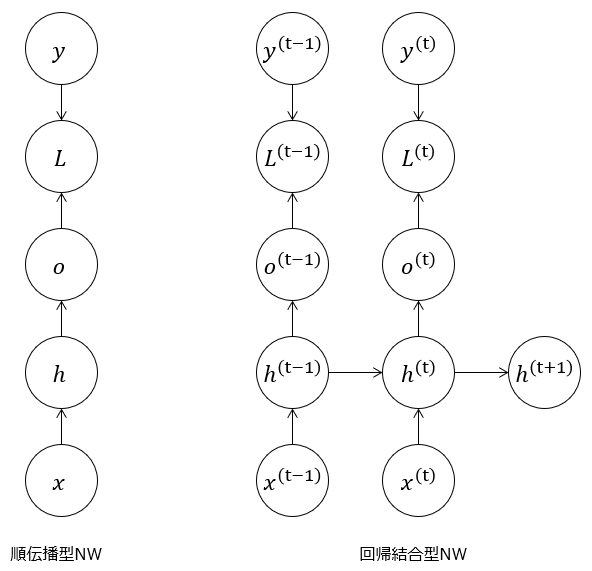  
※補足：
- x：入力
- h ：隠れ層
- o ：出力層
- L ：損失関数
- y ：正解ラベル
- t ：時刻ステップ（1<=t<=T）  

FNNは、「入力-隠れ層-出力」の流れで、上流から下流に一方通行でデータが処理されていきます。それに対してRNNは、過去の情報を取り込む必要があります。  
そのため、1つ前の時間 (t-1) の隠れ層からの情報を、時間 (t)  の隠れ層の入力とします。

なお、図は x(t) と記載していますが、実際は複数の説明変数 x(t)=(x1(t),x2(t),...,xn(t)) で構成されています。

同様に隠れ層も、複数のユニット h(t)=(h1(t),h2(t),...,hi(t)) で構成されています。

ここで h(t-1) は、それまでの過去の情報をすべて含んでいます。  
RNNでは、ある時刻 t の隠れ状態 h(t) は、その1つ前の時刻 t-1 の隠れ状態 h(t-1) と、時刻 t の入力 x(t) を使って計算されます。  
この計算を行う関数を f とすると、h(t)=f(h(t-1),x(t)) と表せます。

たとえば、t=3 の場合、h(t-1) は h(2) となります。これは以下のように計算されます  
（ここで h(0) は初期隠れ状態を表します）。

まず、時刻 t = 1 の隠れ状態は：  
h(1) = f(h(0),x(1))  

次に、時刻 t =2 の隠れ状態は、この h(1) を使って：  
h(2) = f(h(1),x(2))  

したがって、h(2) は具体的に展開すると次のようになります。
h(2) = f(f(h(0),x(1),x(2)))  

RNNには、以下の特徴があります。
- 過去の情報は再帰的に隠れ層へ入力されます
- 入力データの長さに制限はありません。FNNと比較して、非常に長いデータも扱えます
- 時系列データが可変長であっても問題ありません


## Kerasによる基本的なRNNの実装

### Chapter 2.3 RNNの演習
それでは演習として、KerasによるRNNモデルの実装を行ってみましょう。

### ライブラリのimport
まずは必要なライブラリをimportします。

In [1]:
# 必要なライブラリのimport
import numpy as np
import math
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split

# DataFrameですべての列を表示する設定
pd.options.display.max_columns = None

# 生成する乱数を固定させる
np.random.seed(seed=0)

### データセットの作成
今回は時系列のサンプルデータとして、「sin波」のデータを使用します。sin波は音波の基本で、「波の形状」が時系列的な前後関係を持ちます。よって「これまでの波の値」から、「次の波の値」を予測することとします。まずはsin波を生成する関数を用意します。

In [2]:
# サンプリング周波数（1秒あたりのサンプリング数）
F = 100
# 周波数
Hz = 1
# サンプリング秒数
SEC = 5

# sin波の実装
def sin(t):
    return np.sin(2.0 * np.pi * (t * Hz) / F)

In [3]:
"""
波の形状を決めるのは周波数です。「周波数」が大きくなるほど、「波」が細かくなります（高い音になります）。
また「サンプリング周波数」が大きくなるほど、「音質」が良くなります。
上記の関数( def sin(t) )を利用して、sin波のデータセットを作成します。
"""
# sin波のデータセットを作成
t = np.arange(0, F * SEC + 1)
dataset = sin(t)

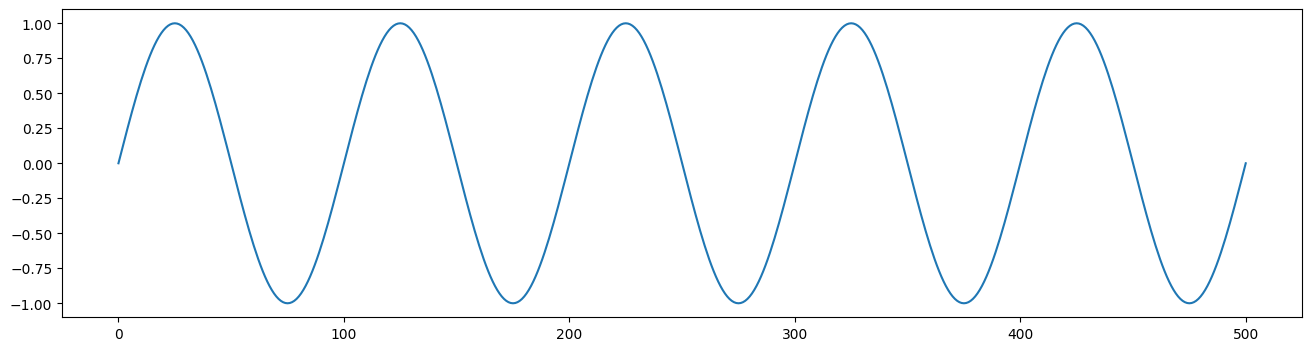

In [4]:
"""グラフで確認してみましょう。"""
# sin波のグラフ表示
plt.figure(figsize=(16, 4))
plt.plot(t, dataset)

In [5]:
"""現実世界で観測されたデータを模して、ノイズを乗せます。ノイズは平均0、標準偏差0.1の正規分布に基づいています。"""
# ノイズを加える
dataset = sin(t) + np.random.normal(loc=0.0, scale=0.1, size=len(t))

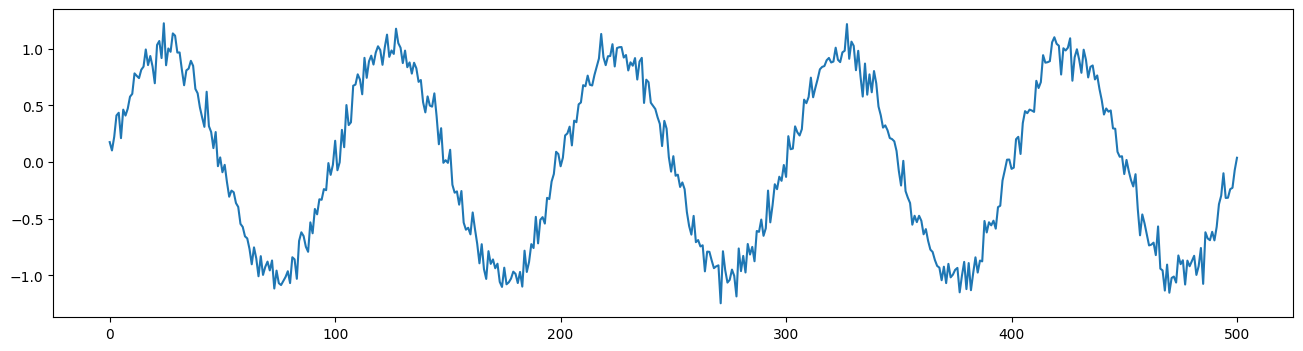

In [6]:
# ノイズを加えたsin波のグラフ表示
plt.figure(figsize=(16, 4))
plt.plot(t, dataset)

### 目的変数と説明変数の作成
次に、目的変数と説明変数を作成します。 まずは「入力データ長」を定義します。

In [14]:
"""
「過去の値」を説明変数、「予測したい値」を目的変数とします。入力データ長が20の場合、たとえば以下のようになります。
- 目的変数：No20、説明変数：No00～19
- 目的変数：No21、説明変数：No01～20
- 目的変数：No22、説明変数：No02～21
- …（以降も同様に続く）…
"""
# 入力データ長（順伝播の長さ）
T = 20

In [15]:
# 説明変数：目的変数の過去の情報
X = []
# 目的変数
Y = []

# 説明変数と目的変数の作成
for i in range(0, len(dataset) - T):
    X.append(dataset[i:i+T])
    Y.append(dataset[i+T])

In [16]:
"""データセットと比較して、X と Y が正しく設定されていることを確認しましょう。"""
# XとYが正しく取得されていることを確認
dataset[0:T+1]

array([0.17640523, 0.10280624, 0.22320703, 0.41147063, 0.43544569,
       0.21128921, 0.46313339, 0.41064357, 0.47143179, 0.57688665,
       0.60218961, 0.78285134, 0.76065088, 0.74113613, 0.81489957,
       0.84238443, 0.99373583, 0.85579085, 0.93613382, 0.84436691,
       0.69575753])

In [17]:
X[0]

array([0.17640523, 0.10280624, 0.22320703, 0.41147063, 0.43544569,
       0.21128921, 0.46313339, 0.41064357, 0.47143179, 0.57688665,
       0.60218961, 0.78285134, 0.76065088, 0.74113613, 0.81489957,
       0.84238443, 0.99373583, 0.85579085, 0.93613382, 0.84436691])

In [18]:
Y[0]

np.float64(0.6957575347117457)

In [19]:
# 学習用にreshape
X = np.array(X).reshape(-1, T, 1)
Y = np.array(Y).reshape(-1, 1)

In [20]:
# 形状を確認
print("Y=", Y.shape, ", X=", X.shape)

Y= (481, 1) , X= (481, 20, 1)


In [25]:
print(Y[:3])

[[0.69575753]
 [1.03394502]
 [1.06873087]]


In [26]:
print(X[:3])

[[[0.17640523]
  [0.10280624]
  [0.22320703]
  [0.41147063]
  [0.43544569]
  [0.21128921]
  [0.46313339]
  [0.41064357]
  [0.47143179]
  [0.57688665]
  [0.60218961]
  [0.78285134]
  [0.76065088]
  [0.74113613]
  [0.81489957]
  [0.84238443]
  [0.99373583]
  [0.85579085]
  [0.93613382]
  [0.84436691]]

 [[0.10280624]
  [0.22320703]
  [0.41147063]
  [0.43544569]
  [0.21128921]
  [0.46313339]
  [0.41064357]
  [0.47143179]
  [0.57688665]
  [0.60218961]
  [0.78285134]
  [0.76065088]
  [0.74113613]
  [0.81489957]
  [0.84238443]
  [0.99373583]
  [0.85579085]
  [0.93613382]
  [0.84436691]
  [0.69575753]]

 [[0.22320703]
  [0.41147063]
  [0.43544569]
  [0.21128921]
  [0.46313339]
  [0.41064357]
  [0.47143179]
  [0.57688665]
  [0.60218961]
  [0.78285134]
  [0.76065088]
  [0.74113613]
  [0.81489957]
  [0.84238443]
  [0.99373583]
  [0.85579085]
  [0.93613382]
  [0.84436691]
  [0.69575753]
  [1.03394502]]]


### データの分割

In [27]:
"""
データの分割を行います。ただし今回は時系列データのため、データのシャッフルは行わず、前半70％を学習データとします。
また、「学習・検証・テスト」の3つに分けています。
"""
# データの分割
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, shuffle=False)
X_train, X_valid, Y_train, Y_valid = train_test_split(X_train, Y_train, test_size=0.3, shuffle=False)

In [28]:
# 形状を確認
print("Y_train=", Y_train.shape, ", X_train=", X_train.shape)
print("Y_valid=", Y_valid.shape, ", X_valid=", X_valid.shape)
print("Y_test=", Y_test.shape, ", X_test=", X_test.shape)

Y_train= (235, 1) , X_train= (235, 20, 1)
Y_valid= (101, 1) , X_valid= (101, 20, 1)
Y_test= (145, 1) , X_test= (145, 20, 1)


### モデルの構築
Kerasでは、RNN層は SimpleRNN を使います。

In [29]:
# 出力数（回帰のため1）
OUT_SIZE = 1
# 隠れ層のユニット数
HIDE_SIZE = 100
# RNNの入力形状: 任意のタイムステップ長, 1つの特徴量
rnn_input_shape = (None, 1)

In [30]:
# モデルの初期化
model = tf.keras.Sequential([
    # 入力層
    tf.keras.Input(shape=rnn_input_shape),
    # RNN層
    tf.keras.layers.SimpleRNN(HIDE_SIZE),
    # 出力層
    tf.keras.layers.Dense(OUT_SIZE, activation='linear')
])

# モデルの構築
model.compile(optimizer = tf.keras.optimizers.Adam(),
              loss='mean_squared_error')

In [31]:
# 学習の実施
log = model.fit(X_train, Y_train, epochs=50, batch_size=32, verbose=True,
                callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss',
                                                         min_delta=0, patience=100,
                                                         verbose=1)],
                validation_data=(X_valid, Y_valid))

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.1708 - val_loss: 0.0304
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0501 - val_loss: 0.0406
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0328 - val_loss: 0.0251
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0201 - val_loss: 0.0178
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0163 - val_loss: 0.0148
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0145 - val_loss: 0.0141
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0136 - val_loss: 0.0136
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0132 - val_loss: 0.0139
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0131 - val_loss: 0.0136
Epoch 10/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0126 - val_loss: 0.0135
Epoch 11/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0124 - val_loss: 0.0135
Epoch 12/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0117 - val_loss: 0.0135
Epoch 13/50


In [32]:
# モデルの構造を表示
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 100)            │        10,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,905 (120.73 KB)

 Trainable params: 10,301 (40.24 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 20,604 (80.49 KB)

モデルの構造を確認しましょう。10,301個のパラメータがあります。

### 学習の経過の確認
学習の経過をグラフで確認しましょう。

Text(0, 0.5, 'crossentropy')

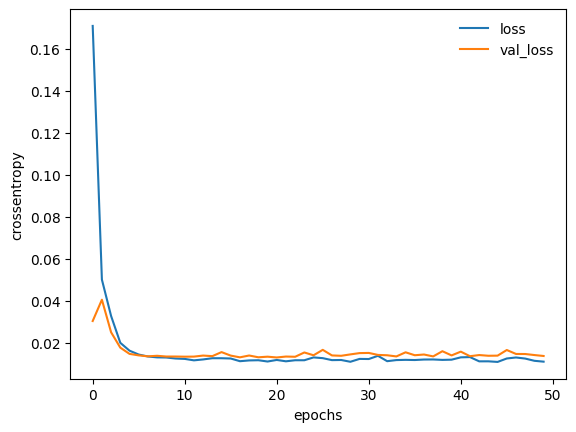

In [33]:
# 学習の経過をグラフ表示
plt.plot(log.history['loss'], label='loss')
plt.plot(log.history['val_loss'], label='val_loss')
plt.legend(frameon=False) # 凡例の表示
plt.xlabel("epochs")
plt.ylabel("crossentropy")

### テストデータによる評価

In [34]:
# 予測
pred_ys = model.predict(X_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


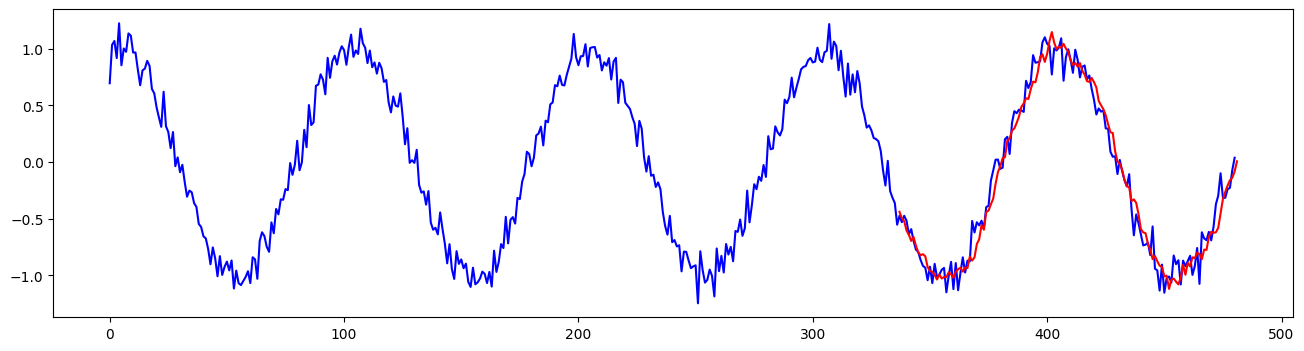

In [35]:
# 正解（青）と予測値（赤）との比較
plt.figure(figsize=(16, 4))
plt.plot(range(0, len(X)), Y, color='blue')
plt.plot(range(len(X_train)+len(X_valid)+1, len(X)+1), pred_ys, color='red')

In [36]:
# MSEを算出
0.5 * ((Y_test - pred_ys) ** 2).sum()

np.float64(0.9030553772432699)

ノイズの影響を強く受けずに、本質的な波形を予測できていることがわかります。

## Chapter 3 長・短期記憶（LSTM）
ここでは、LSTM（Long Short-Term Memory：長・短期記憶）について説明します。

RNNは「過去の隠れ層の出力を引き継ぐ」アイディアにより、時系列データの特徴を学習できます。ところが長期間の時系列データを扱う場合、遠い過去の情報を引き継ぐことが困難になります。「勾配消失」や「勾配爆発」と呼ばれています。

長期依存性があるデータを処理するために、LSTMが開発されました。LSTMは、RNNの隠れ層を「セル」と呼ばれる構造に置き換えています。セルは、過去の情報を保持するための仕組みを持っています。

\[AI要約]

# サマリー

**LSTM**は、RNNで起こる**勾配消失/爆発**を**メモリセル**と **3つのゲート（忘却・入力・出力）** で抑え、**長期依存**を学習できる仕組みです。  
入力と前時刻の隠れ状態からゲートを計算し、セル状態 `C(t)` を更新・保持、活性化した値を出力します。

---

## 詳細な解説

### 内部ドキュメントからの回答

* **位置づけと目的**  
  RNNは時系列を扱える一方、長期になると**遠い過去情報が伝わりにくい**（勾配消失/爆発）課題があります。**LSTM**はこの課題に対応するため、RNNの隠れ層を**セル**構造に置き換え、`過去情報を長く保持できるように設計されています。`
* **LSTMの入出力**  
  仕組みは複雑ですが、毎時刻で **`x(t)`（入力）と `h(t-1)`（前隠れ状態）を受け**、\*\*`h(t)`（出力）\*\*を返す点はRNNと同じで、既存RNNを置換可能です。
* **ゲートと更新式（教材の表記）**  
  候補・ゲートの計算：

  $$
  \begin{aligned}
  f(t)&=\sigma(U_f x(t) + W_f h(t-1) + b_f)\\
  a(t)&=\tanh(U_a x(t) + W_a h(t-1) + b_a)\\
  i(t)&=\sigma(U_i x(t) + W_i h(t-1) + b_i)\\
  o(t)&=\sigma(U_o x(t) + W_o h(t-1) + b_o)
  \end{aligned}
  $$

  セル・出力の更新：

  $$
  C(t)=i(t)\odot a(t)+f(t)\odot C(t\!-\!1),\quad
  h(t)=o(t)\odot \tanh(C(t))
  $$

  （$\odot$：要素積、$\sigma$：シグモイド）  
  直感：**忘却 `f(t)` で捨てる量を決め、入力 `i(t)` と候補 `a(t)` で足す量を決める**→`C(t)` を更新→**出力 `o(t)` が見せる量を調整**して `h(t)` を生成。  
* **教材の実装位置づけ**  
  Lesson12では `tf.keras.layers.LSTM(HIDE_SIZE)` を使い、時系列回帰の例で学習（`loss='mean_squared_error'`）。学習曲線やモデル構造の確認例が掲載されています。  

#### ASCII 図（LSTM1ステップの計算フロー・簡略）

```
x(t)       h(t-1)                   C(t-1)
  │           │                        │
  ├────┬──────┼──────────────┬───────────┤
  │    │      │              │           │
  ▼    ▼      ▼              ▼           ▼
+────────+ +────────+    +────────+   +────────+
| Forget | |  Input |    |Candidate|   | Output |
| gate f | | gate i |    |   a     |   | gate o |
|  σ(.)  | |  σ(.)  |    | tanh(.) |   |  σ(.)  |
+────────+ +────────+    +────────+   +────────+
    │          │              │            │
    │          │              │            │
    └─▶(×)◀───┘              │            │
          │                  │            │
          │        (×)◀─── i(t) ──┐       │
          │             a(t)       │       │
          └───────────▶(＋)◀──────┘       │
                       │                  │
                    +──────+              │
                    | C(t) |─────────▶tanh│
                    +──────+              ▼
                                          (×)◀── o(t)
                                           │
                                           ▼
                                         +──────+
                                         | h(t) |
                                         +──────+
```

注：σ=t=それぞれシグモイド/双曲線正接、(×)は要素積、(＋)は要素和。教材の記号と対応。

---

## 関連情報

* **どのときLSTM?** 長い依存（文脈が遠くにある）・可変長列・ノイズの多い信号など。教材の例でも**ノイズ低減**と**長期傾向**の予測が改善。
* **派生**：双方向LSTM、スタックLSTM、Seq2Seq、Attention/Transformerなどと組み合わせて性能向上。&#x20;

---

## 代表エラー

* **入力形状の不一致**：`(samples, T, features)` に整形せず `LSTM` に渡してエラー。→ **3次元テンソル**へ reshape。
* **`return_sequences` の誤設定**：中間のLSTMで `return_sequences=False` にして**後段RNNへ渡せない**。→ 中間層は **True**。
* **過学習**：小データで大きな隠れユニット。→ **Dropout/Recurrent Dropout**、**早期終了**の利用（教材もEarlyStopping例）。
* **損失関数の選択ミス**：回帰で `categorical_crossentropy` を使う等。→ 回帰は **MSE/MAE**、分類は **CE**。



## LSTMの実装

### Chapter 3.2 LSTMの演習
演習として、KerasによるLSTMモデルの実装を行ってみましょう。  
実装といっても、先ほどの「SimpleRNN」を「LSTM」に変更するだけです。データも、先ほどのものを利用します。

### モデルの構築

In [37]:
# モデルの初期化
model_lstm = tf.keras.Sequential([
    # 入力層
    tf.keras.Input(shape=rnn_input_shape),
    # RNN層
    tf.keras.layers.LSTM(HIDE_SIZE),
    # 出力層
    tf.keras.layers.Dense(OUT_SIZE, activation='linear')
])

# モデルの構築
model_lstm.compile(optimizer = tf.keras.optimizers.Adam(),
                   loss='mean_squared_error')

In [38]:
# 学習の実施
log_lstm = model_lstm.fit(X_train, Y_train, epochs=50, batch_size=32, verbose=True,
                          callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss',
                                                                      min_delta=0, patience=100,
                                                                      verbose=1)],
                          validation_data=(X_valid, Y_valid))

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.2629 - val_loss: 0.1194
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1006 - val_loss: 0.0662
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0566 - val_loss: 0.0456
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0341 - val_loss: 0.0216
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0167 - val_loss: 0.0132
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0129 - val_loss: 0.0132
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0130 - val_loss: 0.0114
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0117 - val_loss: 0.0120
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0122 - val_loss: 0.0121
Epoch 10/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0121 - val_loss: 0.0114
Epoch 11/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0118 - val_loss: 0.0117
Epoch 12/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0122 - val_loss: 0.0118
Epoch 13/50


In [39]:
# モデルの構造を表示
model_lstm.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100)            │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,705 (479.32 KB)

 Trainable params: 40,901 (159.77 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 81,804 (319.55 KB)

### 学習の経過の確認

Text(0, 0.5, 'crossentropy')

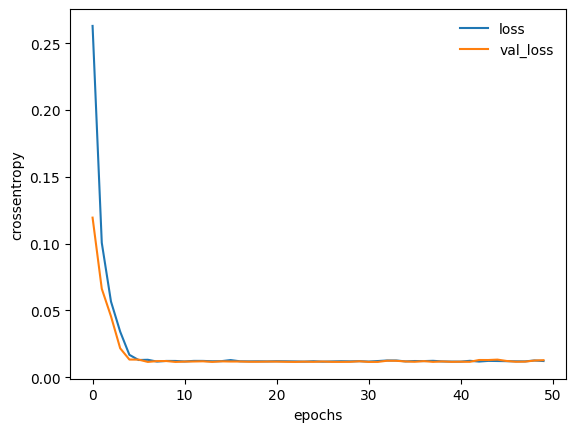

In [40]:
# 学習の経過をグラフ表示
plt.plot(log_lstm.history['loss'], label='loss')
plt.plot(log_lstm.history['val_loss'], label='val_loss')
plt.legend(frameon=False) # 凡例の表示
plt.xlabel("epochs")
plt.ylabel("crossentropy")

### テストデータによる評価

In [41]:
# 予測
pred_ys_lstm = model_lstm.predict(X_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


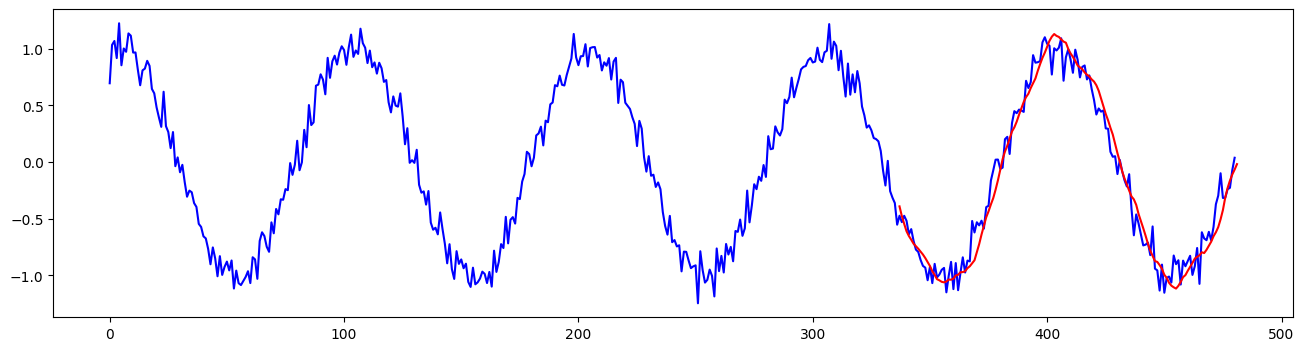

In [42]:
# 正解（青）と予測値（赤）との比較
plt.figure(figsize=(16, 4))
plt.plot(range(0, len(X)), Y, color='blue')
plt.plot(range(len(X_train)+len(X_valid)+1, len(X)+1), pred_ys_lstm, color='red')

予測結果は、以上のとおりです。長期依存性の傾向が反映され、全体としてノイズが除去された「綺麗な予測結果」を得られました。

## Chapter 4 自然言語処理（NLP）の手法・モデル
ここからは、自然言語処理（Natural Language Processing：NLP）にまつわる手法やモデルについて説明します。  
NLPは、テキストデータを扱うための技術です。NLPは、機械翻訳や音声認識などにも活用されています。

たとえば、`これはペンです` という日本語を `This is a pen` という英語に自動で翻訳したいとします。そのための技術を紹介します。

### Chapter 4.1 Seq2Seq
ここまでで紹介したRNNやLSTMは、次に来る値を予測できるものでした。
しかし、翻訳の場合、`これはペンです` という日本語の単語のまとまりを `This is a pen` という英語の単語のまとまりに変換しなければなりません。

単語のまとまりのことを、系列データと言います。 系列データを変換するためには、RNNやLSTMだけでは不充分です。

ここでは、系列データの変換技術である、Seq2Seq（Sequence-to-Sequence：Sequenceは系列データという意味です）について説明します。「Encoder-Decoder」とも呼ばれますが、本レッスンでは Seq2Seq と表記します。

Seq2Seqは、機械翻訳や音声認識などにも活用されているモデルです。

Seq2Seqは、「Encoder」と「Decoder」の2つのRNNを接続した、以下のような構造になっています。機械翻訳を例に説明します。  

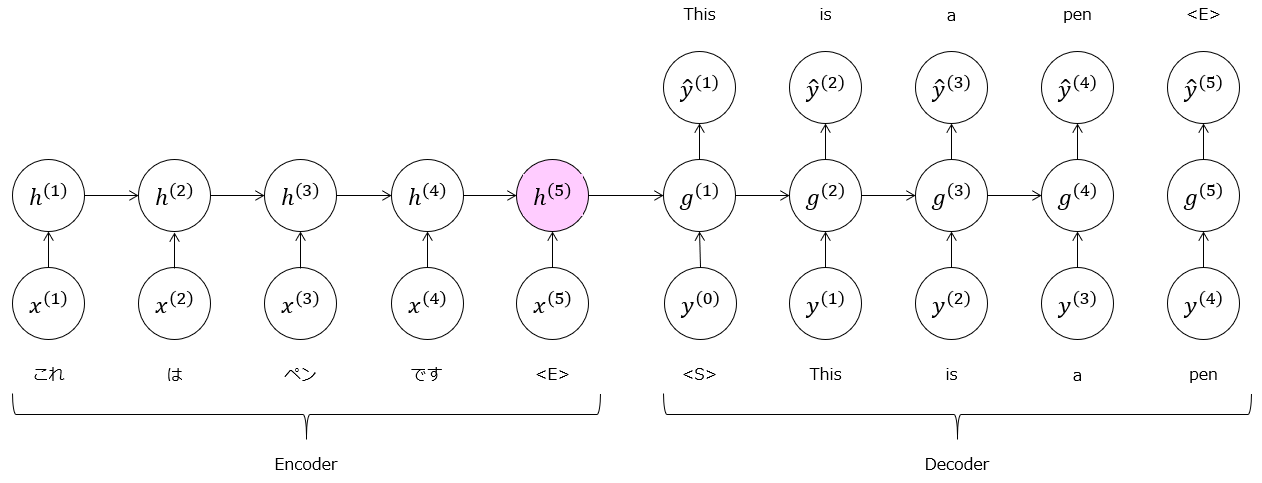  

**Encoder**  
Encoderの入力は、可変長の時系列データです。Encoderは基本的なRNNやLSTMと同様に、入力を受け取り、隠れ層を次の隠れ層に伝えます。ただし出力層はありません。  
```h^{(t)}=f(h^{(t-1)}, x^{(t)})```  
終了文字（図の <E>）などで「入力の終了」を感知したら、順伝播を終了します。Encoderの出力は、「最後の隠れ層の出力」となります。これを「文脈ベクトル」と呼びます。文脈ベクトルは、「固定長のベクトルで、入力データの情報を集約したもの」という位置づけです。

**Decoder**  
Decoderの隠れ層の初期値 g(0) は、「文脈ベクトル c」です。また入力の初期値 y(0) は開始文字（図の <`S> ）で、以降の入力は y(t-1) となります。  
```\hat{y}^{(t)}=g(h^{(t-1)}, y^{(t-1)}, c)```  
つまり Decoder は、「Encoder からの隠れ層の情報」と「1つ前の語」をもとに、次の語は何かを学習するモデルということです。このように、入力に正解ラベルを与えることを「教師強制」と呼びます。

Decoderの学習フェーズでは、前の語という正解ラベルを与えます。そして、次の語を正しく予測できるようサポートします。モデル全体で表すと、説明変数 x と目的変数 y の「対数尤度」が最大になるよう、2つのRNNを学習します。
 ```\log P(y^{(1)}, y^{(2)}, \cdots, y^{(n)} | x^{(1)}, x^{(2)}, \cdots, x^{(m)})```  

**生成器**  
Seq2Seqで予測を行う機構を、「生成器」と呼びます。生成器は学習済の Encoder と Decoder で構成されます。  
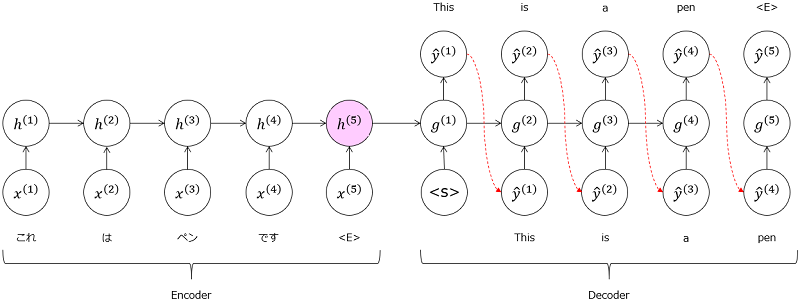  
Encoder は学習フェーズと変わらず、入力を受け取り隠れ層を出力します。Decoder に与える情報は、学習フェーズと異なります。最初に「Encoderの隠れ層の出力」と「開始文字」を与え、予測結果（文字）を次の時刻 t + 1 の入力とするのです（学習フェーズは、「教師強制」により前の語を与えていました）。  
生成器は出力に終了文字が出現したり、出力が規定の長さに達したりしたとき、生成を終了します。

### Chapter 4.2 Attentionメカニズム
先ほどのSeq2Seqにも課題点があります。それを解決する手法が、Attentionメカニズム（注意機構）です。

**Seq2Seqの課題点**  
Seq2Seq は「文脈ベクトル」で入力の情報を要約し、 Decoder の隠れ層の「初期値」として与えました。  
このとき文脈ベクトルは固定長であり、学習データの長短に関わらず一定の大きさのベクトルに情報を要約します。  
つまり、文脈ベクトルの次元（大きさ）によっては、長文の情報が欠落してしまう可能性があります。

また文脈ベクトルは、Decoder全体に対しての入力となります。これは不自然なことで、たとえば `これはペンです` と `This is a pen` では、文章全体の結びつきではなく、`ペン` と `Pen` の結びつきがより強く表されるべきです。

**Attentionの概要**  
「入力と出力の単語の関連性」を取り入れたのが、「Attentionメカニズム」です。  
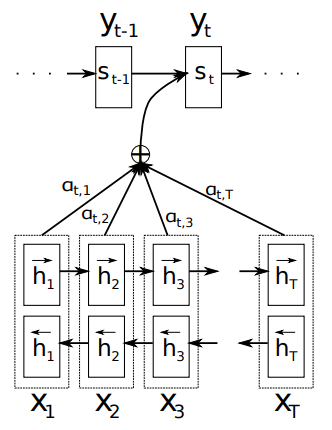  
Attentionメカニズムの基本的な考え方は、デコーダーが各時刻で単語を生成する際に、エンコーダーの入力系列のどの部分に「注意」を向けるべきかを動的に学習することです。これにより、固定長の文脈ベクトル c の代わりに、時刻 t ごとに異なる文脈ベクトル c(t) を計算して利用します。

デコーダーの時刻 t における隠れ状態を st とします。（これは従来のSeq2Seqにおけるデコーダーの隠れ状態に相当します。）
Attentionメカニズムを用いた場合、このデコーダーの隠れ状態 st は、一つ前の隠れ状態 st-1、前の時刻の出力（または正解単語）yt- 1 、そして現在の時刻で計算された文脈ベクトル c(t) を用いて、以下のように計算されます。  
```s_t = f(s_{t-1}, y_{t-1}, c^{(t)})```